---
$$ \large\color{Green}{\textbf{Blinkit Grocery Sales & Outlet Performance Analysis }} $$  $$\large\textbf{Exploratory Data Analysis}$$

---
**Dataset:** BlinkIT Grocery Data (Kaggle)  
**Author:** $\textit{Sasi Kiran}$  
**Date:** May 2026  
**Tool:** **Python [ Pandas, Matplotlib, Seaborn ]**

---



## Table of Contents
1. [Objective](#objective)
2. [Dataset Overview](#dataset-overview)
3. [Data Quality Checks](#data-quality-checks)
4. [Univariate Analysis](#univariate-analysis)
5. [Bivariate Analysis](#bivariate-analysis)
6. [Multivariate Analysis](#multivariate-analysis)
7. [Key Insights](#key-insights)



### **Step 1: Objective**
---
The goal of this EDA is to understand the distribution,
relationships, and data quality of the Blinkit dataset
in order to answer:

1. Which outlet type and location tier drives the highest sales?
2. Which item categories contribute most to revenue?
3. Does fat content or item visibility influence sales?
4. Is there a correlation between outlet size, age, and rating?


### **Step 2: Dataset Overview**

---

This step focuses on understanding the structure and composition of the dataset, including the number of records, feature types, and overall data distribution. This ensures the dataset is suitable for analyzing sales performance across outlets and product categories.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
data = pd.read_excel('/content/BlinkIT Grocery Data.xlsx')
data.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [30]:
# Shape of dataset
print(f'Shape of dataset: \n{"-"*50}\n{data.shape} ')
print()

# columns
print(f'columns: \n{"-"*50}\n{data.columns}')
print()


# Data types
print(f'Data type of each column:\n{"-"*50} ')
display(data.dtypes)




Shape of dataset: 
--------------------------------------------------
(8523, 12) 

columns: 
--------------------------------------------------
Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

Data type of each column:
-------------------------------------------------- 


,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [31]:
# Missing Values

print('Missing values: ')
print('-'*50)
display(data.isnull().sum())
print()

# Percentage of null values
print('null value percentage :')
print('-'*50)
display((data.isnull().sum())/len(data)*100)

Missing values: 
--------------------------------------------------


,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Item Weight,1463



null value percentage :
--------------------------------------------------


,0
Item Fat Content,0.000000
Item Identifier,0.000000
Item Type,0.000000
Outlet Establishment Year,0.000000
Outlet Identifier,0.000000
Outlet Location Type,0.000000
Outlet Size,0.000000
Outlet Type,0.000000
Item Visibility,0.000000
Item Weight,17.165317


In [32]:
# Unique values
print('Unique values: ')
print('-'*50)
display(data.nunique())
print()

# Duplicate values
print('Duplicate values: ')
print('-'*50)
display(data.duplicated().sum())


Unique values: 
--------------------------------------------------


,0
Item Fat Content,5
Item Identifier,1559
Item Type,16
Outlet Establishment Year,9
Outlet Identifier,10
Outlet Location Type,3
Outlet Size,3
Outlet Type,4
Item Visibility,7880
Item Weight,415



Duplicate values: 
--------------------------------------------------


np.int64(0)

In [33]:
# Statistical Summary
print('Statistical Summary: ')
print('-'*50)
display(data.describe())


Statistical Summary: 
--------------------------------------------------


,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


### **Step 3: Data Quality Checks**
---

This step focuses on identifying and handling data inconsistencies, missing values, and anomalies to ensure the dataset is accurate, reliable, and suitable for analysis.


In [34]:
cat_cols = [
    'Item Fat Content',
    'Item Type',
    'Outlet Type',
    'Outlet Location Type',
    'Outlet Size'
]

In [35]:
import pandas as pd

unique_summary = pd.DataFrame({
    col: pd.Series(data[col].unique()) for col in cat_cols
})

unique_summary

,Item Fat Content,Item Type,Outlet Type,Outlet Location Type,Outlet Size
0,Regular,Fruits and Vegetables,Supermarket Type1,Tier 1,Medium
1,Low Fat,Health and Hygiene,Supermarket Type2,Tier 3,Small
2,low fat,Frozen Foods,Grocery Store,Tier 2,High
3,LF,Canned,Supermarket Type3,NaN,NaN
4,reg,Soft Drinks,NaN,NaN,NaN
5,NaN,Household,NaN,NaN,NaN
6,NaN,Snack Foods,NaN,NaN,NaN
7,NaN,Meat,NaN,NaN,NaN
8,NaN,Breads,NaN,NaN,NaN
9,NaN,Hard Drinks,NaN,NaN,NaN


In [36]:
# Fixing Inconsistent labels
data['Item Fat Content']=data['Item Fat Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
})


In [37]:
data['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [38]:
# Missing Values filled with frequent category
# Impute missing values in specific columns using a dictionary-based mapping

data.fillna({
    'Item Fat Content':data['Item Fat Content'].mode()[0],
    'Outlet Type': data['Outlet Type'].mode()[0],
    'Outlet Location Type': data['Outlet Location Type'].mode()[0]
})

data['Outlet Size'] = data['Outlet Size'].fillna("Unknown")


In [39]:
data.sample(15)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
7215,Regular,FDS31,Fruits and Vegetables,2015,OUT045,Tier 2,High,Supermarket Type1,0.044282,13.100,178.5318,4.0
2611,Low Fat,NCM17,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.070791,NaN,46.4086,4.2
5717,Low Fat,FDI26,Canned,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.035029,5.940,179.8344,1.5
4714,Low Fat,FDS12,Baking Goods,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.174828,9.100,127.2362,3.6
6149,Regular,FDJ33,Snack Foods,2017,OUT035,Tier 2,Small,Supermarket Type1,0.088305,8.895,123.4730,4.0
3903,Low Fat,NCR53,Health and Hygiene,2018,OUT019,Tier 1,Small,Grocery Store,0.253948,NaN,223.8404,3.9
4542,Low Fat,NCO30,Household,2014,OUT013,Tier 3,High,Supermarket Type1,0.015712,19.500,181.8608,3.7
701,Low Fat,DRM11,Hard Drinks,2014,OUT013,Tier 3,High,Supermarket Type1,0.066015,6.570,259.7278,4.5
6931,Low Fat,NCX05,Health and Hygiene,2015,OUT045,Tier 2,Small,Supermarket Type1,0.097259,15.200,114.8492,4.0
7771,Low Fat,FDB16,Dairy,2014,OUT013,Tier 3,High,Supermarket Type1,0.044888,8.210,87.3198,4.0


### Section Summary

- Missing values were identified across several categorical columns.
- Inconsistent values in Item Fat Content were standardized (e.g., "LF", "low fat" → "Low Fat").
- Missing values in categorical columns such as Outlet Type and Outlet Location Type were imputed using the most frequent category (mode).
- For Outlet Size, missing values were treated as a separate category ("Unknown") to preserve information.
- Random imputation was avoided to maintain data integrity.
- The proportion of missing values was considered before deciding whether to drop or impute data.

### **Step 4: Univariate Analysis**
---

Univariate analysis involves examining a single variable to understand its distribution, central tendency, spread, and potential anomalies. It helps identify patterns and prepares the data for deeper analysis.




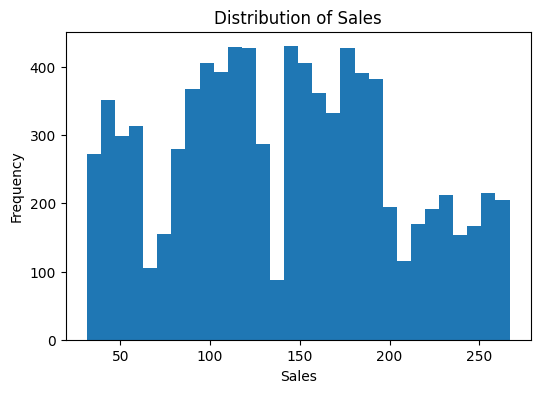

In [40]:
# Plotting Histogram (distribution)
plt.figure(figsize=(6,4))
plt.hist(data['Sales'], bins=30)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

#### Sales Distribution

Observation:
- Sales values are spread across multiple ranges, with higher concentration between 65–130 and 140–200.
- There are also some lower sales values in the 25–55 range.

Insight:
- The distribution appears fairly spread out without a single dominant peak, indicating variability in item performance.
- There is no extreme skew, suggesting sales are relatively balanced across items.

Business Impact:
- Sales are not concentrated in a small group of items, indicating a diverse contribution to revenue.


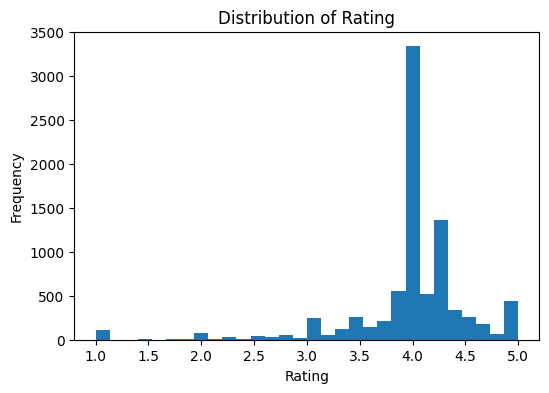

In [41]:
plt.figure(figsize=(6,4))
plt.hist(data['Rating'], bins=30)
plt.title('Distribution of Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

#### Rating Distribution

Observation:
- Majority of ratings are concentrated between 4.0 and 4.5, with very few low ratings.

Insight:
- The distribution is slightly left-skewed, indicating most products receive high ratings.

Business Impact:
- Overall customer satisfaction is high.
- Ratings may have limited variability, so they might not strongly differentiate product performance.

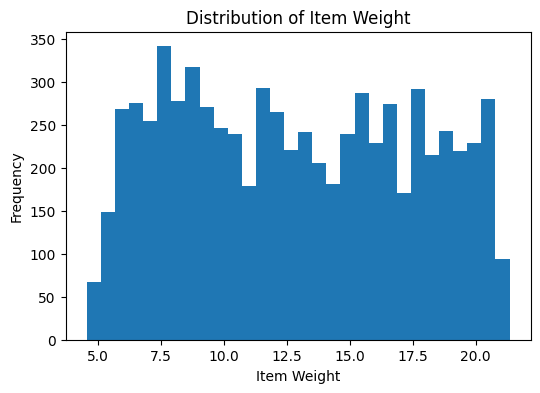

In [42]:
plt.figure(figsize=(6,4))
plt.hist(data['Item Weight'], bins=30)
plt.title('Distribution of Item Weight')
plt.xlabel('Item Weight')
plt.ylabel('Frequency')
plt.show()

#### Item Weight Distribution

Observation:
- Item weight values are distributed across the entire range (approximately 5 to 21).
- No strong peaks or clustering observed.

Insight:
- The distribution is fairly uniform without significant skewness.

Business Impact:
- Item weight is well diversified and is unlikely to bias sales analysis.
- It may not be a strong standalone predictor of sales performance.

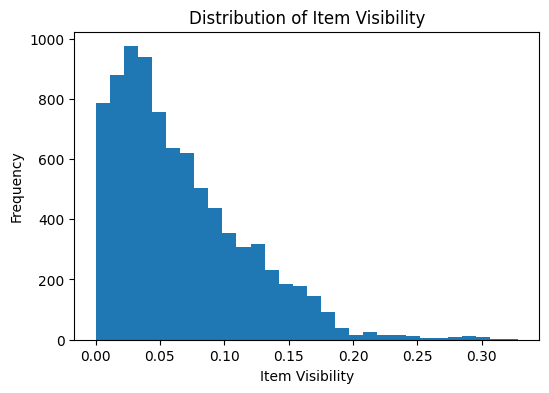

In [43]:
plt.figure(figsize=(6,4))
plt.hist(data['Item Visibility'], bins=30)
plt.title('Distribution of Item Visibility')
plt.xlabel('Item Visibility')
plt.ylabel('Frequency')
plt.show()

#### Item Visibility Distribution

Observation:
- Item visibility values are heavily concentrated in the lower range (0.01–0.06), with a peak around ~0.03–0.04.
- The distribution gradually decreases as visibility increases, with very few items having high visibility (>0.20).

Insight:
- The distribution is strongly right-skewed, indicating that most items have low visibility while only a small number of items receive high display exposure.

Business Impact:
- Most items are allocated limited display space, which may restrict their exposure to customers.
- A small subset of items receives significantly higher visibility, suggesting possible prioritization strategies.


### **Step 5: Bivariate Analysis**
---
Bivariate analysis involves analyzing the relationship between two variables to understand how one variable influences or is associated with another. It helps identify patterns, correlations, and potential drivers of key metrics.

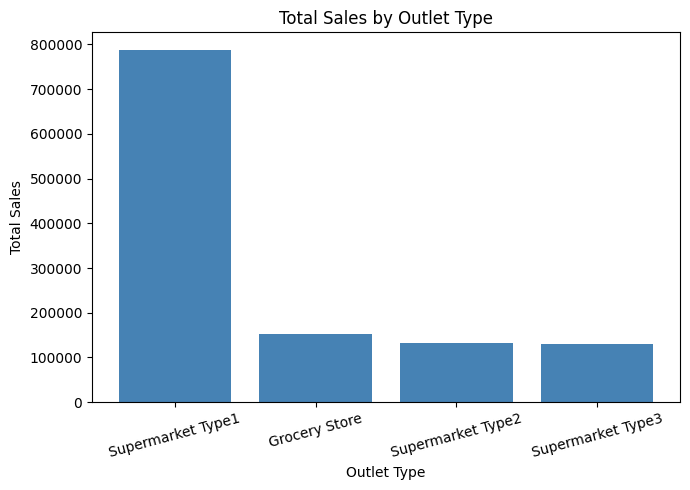

In [48]:
# Group and aggregate
outlet_sales = data.groupby('Outlet Type')['Sales'].sum().sort_values(ascending=False)


plt.figure(figsize=(7, 5))
plt.bar(outlet_sales.index, outlet_sales.values, color='steelblue')
plt.title('Total Sales by Outlet Type')
plt.xlabel('Outlet Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [49]:
data.groupby('Outlet Type')['Outlet Identifier'].nunique()

,Outlet Identifier
Outlet Type,
Grocery Store,2
Supermarket Type1,6
Supermarket Type2,1
Supermarket Type3,1


In [50]:
data.groupby('Outlet Type')['Sales'].mean()

,Sales
Outlet Type,
Grocery Store,140.294690
Supermarket Type1,141.213895
Supermarket Type2,141.678638
Supermarket Type3,139.801791


#### Sales Performance by Outlet Type

Observation:
- Average sales per item are nearly identical (~140) across all outlet types, with minimal variation.

Insight:
- Supermarket Type1’s higher total sales is largely driven by scale (greater outlet presence), rather than superior per-item performance.
- There is no significant difference in efficiency across outlet formats.

Business Impact:
- Revenue growth is more dependent on expanding outlet presence rather than favoring a specific outlet type.
- Strategic expansion in high-demand locations is likely to drive proportional revenue growth across formats.

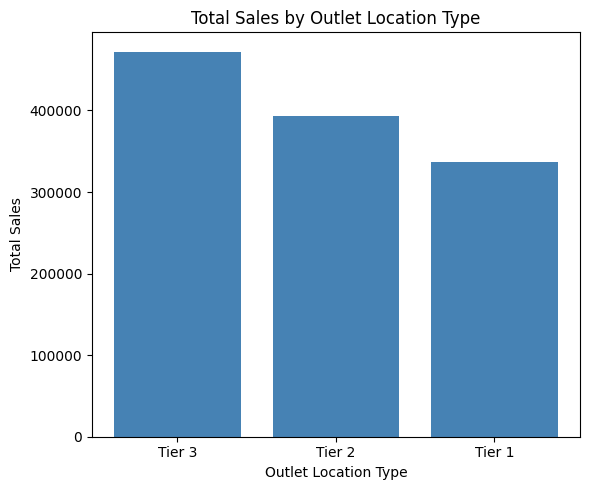

In [52]:
location_sales = data.groupby('Outlet Location Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 5))
plt.bar(location_sales.index, location_sales.values, color='steelblue')
plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [53]:
# Average sales per item by outlet location type
data.groupby('Outlet Location Type')['Sales'].mean()

,Sales
Outlet Location Type,
Tier 1,140.870106
Tier 2,141.167198
Tier 3,140.935234


In [54]:
# Count of unique outlets per location tier - understand if total sales difference is due to outlet count
data.groupby('Outlet Location Type')['Outlet Identifier'].nunique()

,Outlet Identifier
Outlet Location Type,
Tier 1,3
Tier 2,3
Tier 3,4


In [56]:
# Total sales by outlet location type - identify which tier contributes most to overall revenue
data.groupby('Outlet Location Type')['Sales'].sum()

,Sales
Outlet Location Type,
Tier 1,336397.8120
Tier 2,393150.6476
Tier 3,472133.0332


In [57]:
# Sales per outlet  - remove outlet count bias to find true per-store efficiency
total = data.groupby('Outlet Location Type')['Sales'].sum()
count = data.groupby('Outlet Location Type')['Outlet Identifier'].nunique()
(total / count).round(2)

,0
Outlet Location Type,
Tier 1,112132.60
Tier 2,131050.22
Tier 3,118033.26


#### Sales Performance by Location Tier

Observation:
- Tier 3 contributes the highest total sales (472K) with 4 outlets.
- Tier 2 (393K) and Tier 1 (336K) have the same number of outlets (3 each).
- Average sales per item remain consistent across all tiers (141).

Insight:
- Tier 3’s higher total sales is partially driven by having more outlets.
- Despite equal outlet counts, Tier 2 generates higher total sales than Tier 1, suggesting potentially stronger per-outlet performance.
- This indicates that location tier may influence sales performance beyond just outlet count.

Business Impact:
- Tier 2 locations show promising performance and may represent a strong opportunity for expansion.


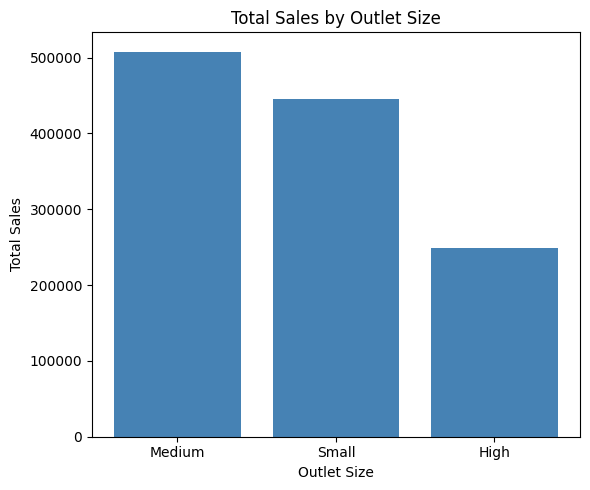

In [58]:
outlet_size_sales = data.groupby('Outlet Size')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 5))
plt.bar(outlet_size_sales.index, outlet_size_sales.values, color='steelblue')
plt.title('Total Sales by Outlet Size')
plt.xlabel('Outlet Size')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()


In [59]:
# Average sales per item by outlet size
data.groupby('Outlet Size')['Sales'].mean()

,Sales
Outlet Size,
High,142.037414
Medium,139.877647
Small,141.699322


In [61]:
# Count unique outlets per size
data.groupby('Outlet Size')['Outlet Identifier'].nunique()

,Outlet Identifier
Outlet Size,
High,4
Medium,6
Small,6


In [63]:
# Distribution of outlet types within each outlet size
# Purpose: understand which outlet format drives medium/small sales
data.groupby(['Outlet Size', 'Outlet Type'])['Outlet Identifier'].nunique()

Outlet Size  Outlet Type      
High         Grocery Store        1
             Supermarket Type1    3
Medium       Grocery Store        1
             Supermarket Type1    3
             Supermarket Type2    1
             Supermarket Type3    1
Small        Grocery Store        2
             Supermarket Type1    4
Name: Outlet Identifier, dtype: int64

#### Sales Performance by Outlet Size (with Type Context)

Observation:
- Medium and Small outlets both have 6 outlets, but Medium generates higher total sales (508K vs 447K).
- Supermarket Type1 is the most common format across all size categories (High, Medium, Small).

Insight:
- Higher total sales in certain segments appear to be driven primarily by outlet presence (count), particularly of Supermarket Type1.
- Average sales per item are similar (141) across segments, suggesting limited variation in per-item performance.
- This indicates scale (number of outlets) may be a stronger contributor to total sales than outlet size alone.

Business Impact:
- Revenue growth is likely influenced by expanding outlet presence, especially in formats that already have scale.
- While Supermarket Type1 contributes significantly to total sales


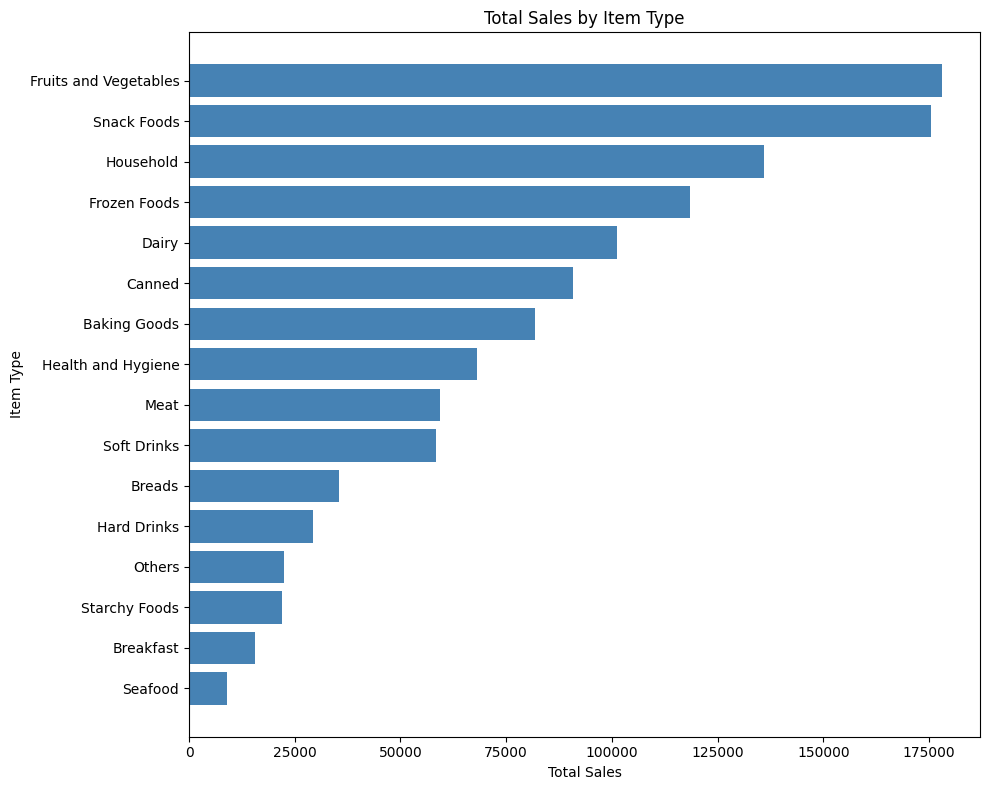

In [66]:
# Total sales by item type - identify which product categories drive most revenue
itemtype_sales = data.groupby('Item Type')['Sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(itemtype_sales.index, itemtype_sales.values, color='steelblue')
plt.title('Total Sales by Item Type')
plt.xlabel('Total Sales')
plt.ylabel('Item Type')
plt.tight_layout()
plt.show()

In [67]:
# Average sales per item type
data.groupby('Item Type')['Sales'].mean().round(2).sort_values(ascending=False)

,Sales
Item Type,
Household,149.42
Dairy,148.50
Starchy Foods,147.84
Snack Foods,146.19
Fruits and Vegetables,144.58
Seafood,141.84
Breakfast,141.79
Breads,140.95
Meat,139.88


#### Sales Performance by Item Type

Observation:
- Total sales vary significantly across the 16 item types.
- Average sales per item range between approximately $126 and $149, indicating noticeable variation across categories.

Insight:
- Unlike outlet-based analysis where average sales were nearly identical (~$141), item types show moderate variation in average sales performance.
- This suggests that product category may influence sales value beyond just outlet scale, though the variation is not extremely large.

Business Impact:
- Product mix optimization may offer an opportunity to improve revenue by focusing on higher-performing categories.


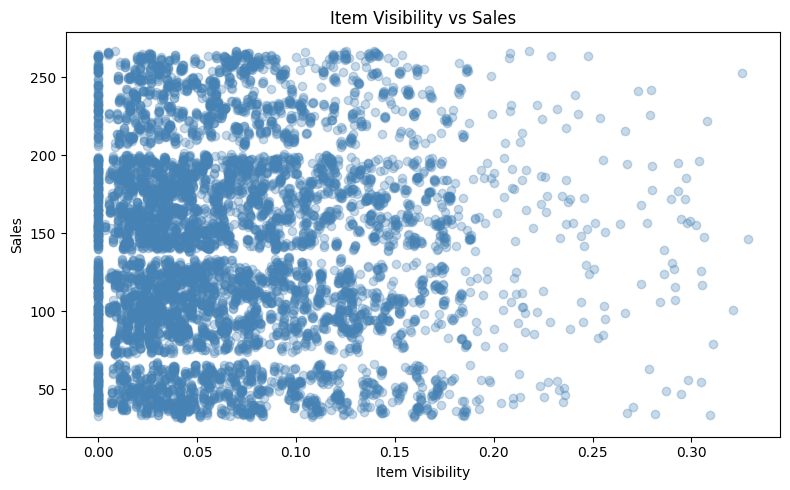

In [68]:
# Scatter plot: Item Visibility vs Sales - test hypothesis — does higher shelf visibility drive more sales?
plt.figure(figsize=(8, 5))
plt.scatter(data['Item Visibility'], data['Sales'],
            alpha=0.3, color='steelblue')
plt.title('Item Visibility vs Sales')
plt.xlabel('Item Visibility')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

#### Sales vs Item Visibility

Observation:
- Data points are widely scattered across all visibility levels with no clear trend.
- Most items have low visibility (0.01–0.10), but sales vary significantly within this range.

Insight:
- There is no strong correlation between item visibility and sales.
- Both high and low visibility items exhibit a wide range of sales values, indicating visibility alone does not drive performance.

Business Impact:
- Increasing visibility alone may not guarantee higher sales.
- Other factors such as product type, pricing, and outlet characteristics likely play a more significant role in influencing sales.

### **Step 6: Multivariate Analysis**
---
Multivariate analysis involves examining the relationship between three or more variables simultaneously to understand how multiple factors together influence a target variable.

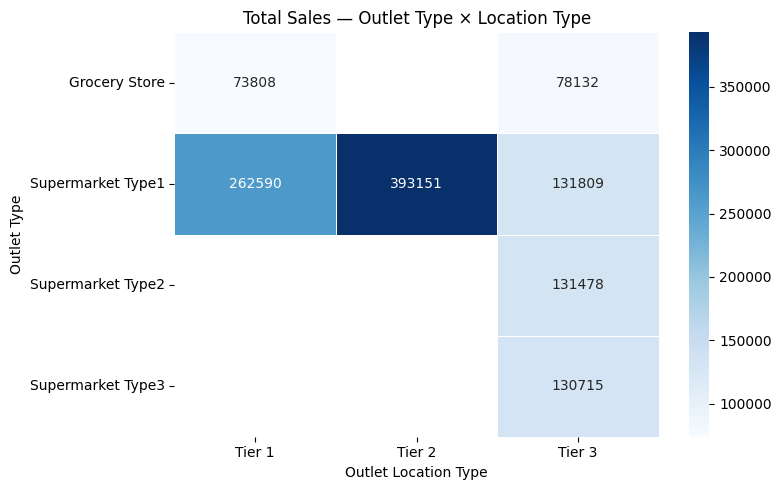

In [70]:
import seaborn as sns

# Outlet Type vs Location Type - To find which combination drives highest sales
pivot = data.pivot_table(
    values='Sales',
    index='Outlet Type',
    columns='Outlet Location Type',
    aggfunc='sum'
).round(2)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            linewidths=0.5)
plt.title('Total Sales — Outlet Type × Location Type')
plt.tight_layout()
plt.show()

#### Sales by Outlet Type and Location Tier

Observation:
- Supermarket Type1 is the only outlet format present across all three location tiers.
- The highest total sales combination is Supermarket Type1 in Tier 2 (393K), followed by Type1 in Tier 1 (262K) and Tier 3 (131K).
- Other outlet formats are unevenly distributed, with most appearing only in Tier 3, limiting direct comparisons across tiers.

Insight:
- Supermarket Type1 in Tier 2 generates the highest total sales, suggesting a strong association between this format and location.
- This supports earlier findings that both outlet type and location influence sales performance.
- However, uneven distribution of outlet formats across tiers makes it difficult to isolate performance effects from structural bias.

Business Impact:
- Tier 2 locations with Supermarket Type1 show strong revenue potential and may be attractive for expansion.
- However, further analysis is needed to evaluate per-outlet efficiency and control for outlet distribution bias.
- Expanding other outlet formats into Tier 1 and Tier 2 could help test untapped market potential.

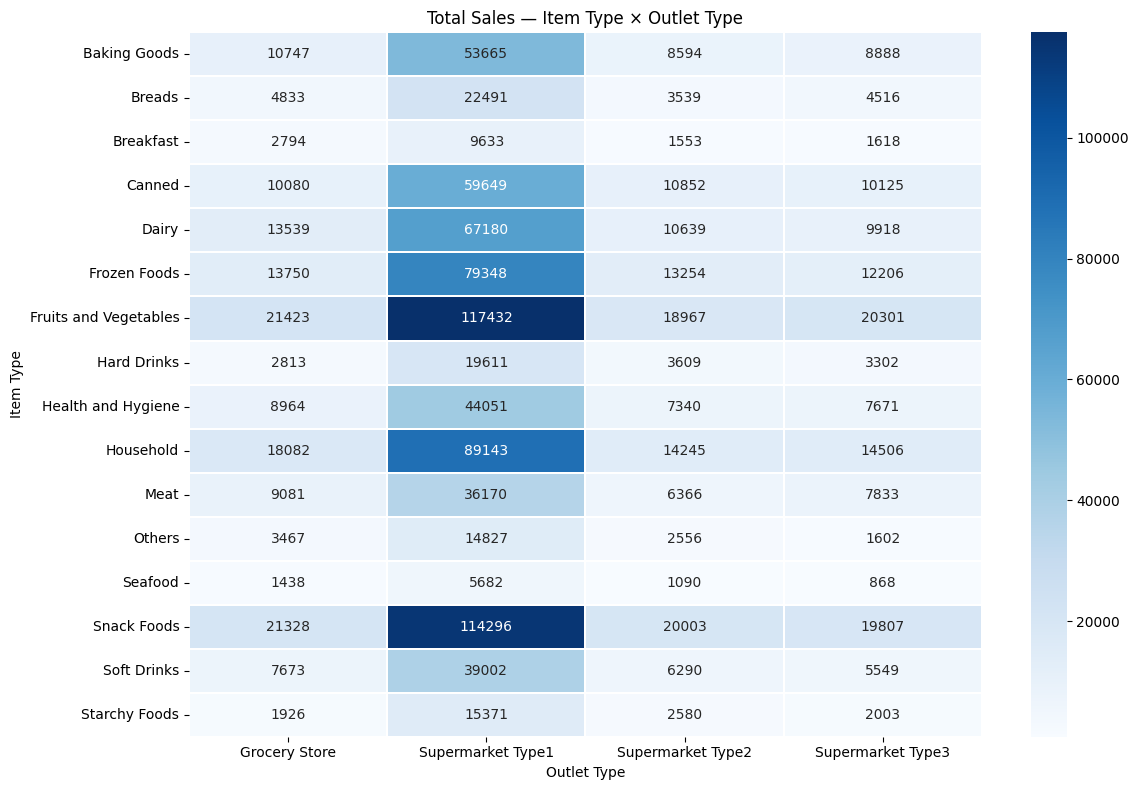

In [71]:
# Sales by Item Type × Outlet Type - identify which product categories perform best in which store format
pivot = data.pivot_table(
    values='Sales',
    index='Item Type',
    columns='Outlet Type',
    aggfunc='sum'
).round(2)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='Blues',
            linewidths=0.2)
plt.title('Total Sales — Item Type × Outlet Type')
plt.tight_layout()
plt.show()

### Multivariate Analysis: Item Type × Outlet Type

Observation:
- Supermarket Type1 generates the highest total sales across all item categories.
- Top-performing categories across outlet types include Fruits & Vegetables, Snack Foods, and Household items.

Insight:
- The dominance of Supermarket Type1 across all categories suggests that its higher total sales are driven by scale (greater presence or volume) rather than category-specific advantage.
- High-performing categories such as Fruits & Vegetables and Snack Foods consistently generate strong sales across all outlet types, indicating strong inherent demand.
- Category performance is relatively stable across outlet formats, suggesting product demand is a stronger driver than outlet format for these categories.

Business Impact:
- Inventory and promotion strategies should prioritize high-demand categories like Fruits & Vegetables and Snack Foods, as they contribute significantly to revenue across all outlet types.
- Since category performance is consistent across outlet formats, optimizing product mix may yield better returns than focusing solely on outlet type.
- Supermarket Type1’s scale advantage should be leveraged, but category-level optimization can further enhance revenue across all outlet formats.

### **Step 7: Key Insights**
---
#### 1. Supermarket Type1 and Tier 2 shows the highest total revenue combination
- This combination generates the highest observed total sales (~$393K), indicating strong performance where outlet format and location align.

#### 2. Total sales are largely influenced by outlet scale rather than efficiency
- Average sales per item are similar (~$141) across outlet types, suggesting total sales differences are primarily driven by outlet presence rather than inherent format efficiency.

#### 3. Tier 2 cities show stronger revenue potential compared to Tier 1
- With equal outlet counts, Tier 2 generates higher total sales than Tier 1, indicating potentially stronger demand or better market conditions.

#### 4. Fruits & Vegetables, Snack Foods, and Household are key revenue-driving categories
- These categories consistently contribute the highest sales across outlet formats, highlighting strong and stable demand.

#### 5. Item visibility shows weak relationship with sales
- Both visual and statistical analysis indicate minimal correlation between visibility and sales, suggesting other factors play a more significant role.

#### 6. Seafood and Breakfast categories show relatively lower sales performance
- These categories contribute lower sales compared to others and may require further analysis to evaluate demand, positioning, or promotional strategy.